In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn

### 1D chain example from the paper 
- input = 31 x 1 coordinates
- output = 31 x 1 displacements
- the left-most atom is fixed
- constant force is applied on right-most atom only
- 3 rep-atoms 
- 1 independent parameter per atom (the NN is shared across all atoms)
- 1 hidden layer
- 3 neurons
- swish activation $ \qquad f(\beta x) = x/(1 + e^{-\beta x})$
- adam optimizer
- learning rate = $10^{-4}$

In [2]:
# swish activation
class Swish(nn.Module):
    def forward(self,x):
        return x * torch.sigmoid(x)

In [14]:
# the neural-network for 1D 
class NeuralNetwork1D(nn.Module):
    def GlorotInitWeights(self, module):
        if isinstance(module,nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)
        
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential( # create a NN with 1 hidden layer
            nn.Linear(in_features = 1, out_features = 3), # input layer. input 1 feature. outputs 3 features
            Swish(),        # activation function (swish)
            nn.Linear(in_features = 3 , out_features = 1)  # output layer. input 3 features. outputs 1 feature
        )
        self.apply(self.GlorotInitWeights)

    def forward(self,x):
        return self.net(x)
        

In [5]:
# Lennard-Jones-6 potential with epsilon = 1.0, sigma = 1.0
def LennardJones(r, epsilon=1.0, sigma=1.0):
    sigma_r_6 = (sigma/r)**6
    return 4.0 * epsilon * (sigma_r_6**2 - sigma_r_6)

In [7]:
# evaluate interaction energy of atom_i located at x[i] with atom_i-1,atom_i-2,atom_i+1,atom_i+2
def AtomicEnergy1D(i,x,neigh_dist=2):
    N = x.shape[0]
    Ei = torch.tensor(0.0, dtype=x.dtype,device=x.device) # initialize energy of atom_i as 0

    for offset in range(1,neigh_dist + 1):
        for j in [i - offset, i + offset]:
            if 0 <= j < N:
                r = torch.abs(x[i,0] - x[j,0]) # distance between atom_i and atom_j
                Ei = Ei + 0.5 * LennardJones(r) # factor of 0.5 to prevent double counting
    return Ei

In [129]:
## 1D problem setup 
N = 31 # number of atoms 
P = -20.0 # external load 
r0 = (4097.0/2028.0) ** (1.0/6.0) # LJ spacing from paper. slightly larger than infinite-chain's equilibrium separation
x0_np = r0 * torch.arange(N,dtype=torch.float64).reshape(-1,1) # 1D grid 
x0 = x0_np.clone() # initialized positions

# normalize 
x_in = (x0 - x0.mean()) / x0.std()

model = NeuralNetwork1D().to(torch.float64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# boundary-condition mask
mask = torch.ones((N,1),dtype=torch.float64)
mask[0,0] = 0.0

# initial guess 
u0 = torch.zeros((N,1),dtype=torch.float64)

# rep-atoms for continuum region
rep_idx = [6,15,23]
weights = [8.0,9.0,8.0]
atomistic_idx = list(range(0,3)) + list(range(28,31))
colors = ['black']*3 + ['orange']*3 + ['red'] + ['orange']*4 + ['green']*4 + ['red'] + ['green']*4 + ['blue']*3 + ['red'] + ['blue']*4 + ['black']*3

energy = torch.tensor(0.0, dtype = torch.float64) 
loss = energy - P * u0[-1,0]

x_history = [x0.detach()]
loss_history = [loss.detach()]
energy_history = [energy.detach()]

for epoch in range(10000):
    optimizer.zero_grad()

    u_raw = model(x_in) # predicted coordinates 
    u = mask * u_raw + u0 # apply boundary conditions 
    x = x0 + u # apply displacements to the unnormalized-coords

    # evaluate energy (for loss functin)
    energy = torch.tensor(0.0, dtype = torch.float64) 
    # evaluate energy of atomistic_region
    for i in atomistic_idx: 
        energy += AtomicEnergy1D(i,x)
    # evaluate energy of continuum region using rep-atom-weights
    for i,w in zip(rep_idx,weights):
        energy += w * AtomicEnergy1D(i,x)

    work = P * u[-1,0]

    loss = energy - work 

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(epoch, float(loss.detach()), float(u[-1,0].detach()))

        x_history.append(x.detach())
        loss_history.append(loss.detach())
        energy_history.append(energy.detach())
    


0 -31.53051804643925 -0.038832755651850265
1000 -39.508947764520414 -0.4450038781667429
2000 -47.55180143248718 -0.87036812416651
3000 -55.9984708109732 -1.3512032785349701
4000 -64.0967406112625 -1.8851432768503666
5000 -70.50665357346627 -2.4184693718132344
6000 -74.37477255831628 -2.883147660348137
7000 -76.03890959492053 -3.20431190199022
8000 -76.5370443657008 -3.3711521851501365
9000 -76.62522239012438 -3.434948796373315


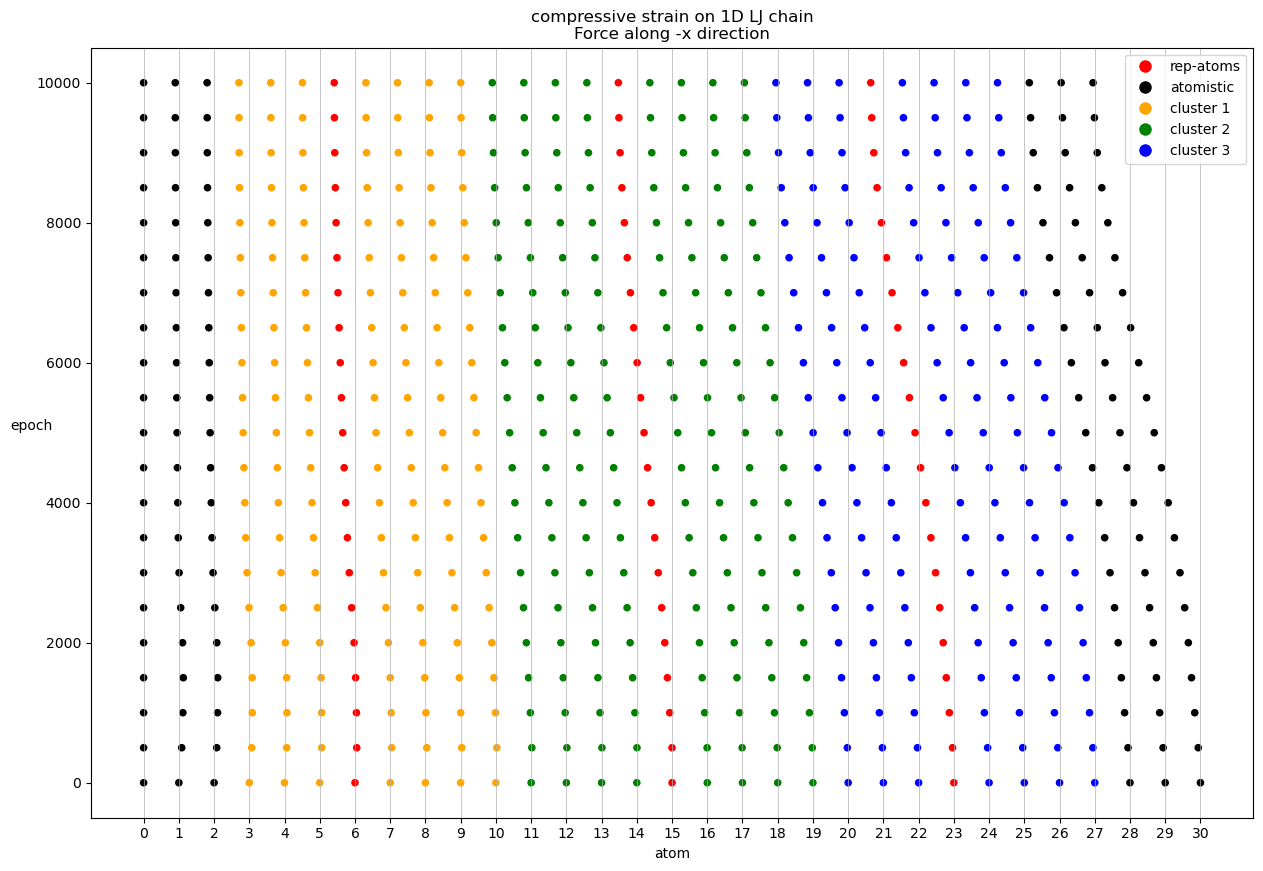

In [154]:
plt.figure(figsize=(15,10))
for i in range(0,len(x_history)):
    xh = x_history[i]
    plt.scatter(xh.numpy().reshape(N), np.full(N,i*500),c=colors,s=20)

plt.xticks(x0.numpy().reshape(N),np.arange(N))
plt.xlabel('atom')
plt.ylabel('epoch',rotation=0)
plt.grid(axis='x',lw=0.5)
plt.title("compressive strain on 1D LJ chain\nCompressive Force along -x direction")

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='red', markeredgecolor='red',markersize=8, label='rep-atoms'),
    Line2D([0], [0], marker='o', color='none',markerfacecolor='black', markeredgecolor='black',markersize=8, label='atomistic'),
    Line2D([0], [0], marker='o', color='none',markerfacecolor='orange', markeredgecolor='orange',markersize=8, label='cluster 1'),
    Line2D([0], [0], marker='o', color='none',markerfacecolor='green', markeredgecolor='green',markersize=8, label='cluster 2'),
    Line2D([0], [0], marker='o', color='none',markerfacecolor='blue', markeredgecolor='blue',markersize=8, label='cluster 3'),
]

plt.legend(handles=legend_handles)

plt.show()